# Assignment 3 – Topic Modeling and Clustering for Online Social Media Data

*Due: Friday January 10 at 17:00 CET*

In the third assignment of the course Applications of Machine Learning (INFOB3APML), you will learn to use topic modeling and clustering to identify topics in online social media data. The objectives of this assignment are:
- understand and process the text data
- use the clustering algorithm to determine clusters in real-life data
- use the Latent Dirichlet Allocation algorithm to identify discussed topics in real-life text data
- use the visualization tools to validate the results of unsupervised learning and interpret your findings
- reflect on the difference between two type of unsupervised learning algorithms

In this assignment, you are going to discover the different ‘topics’ from a real social media text dataset. The project is divided into two parts (4 subtasks):

- The first part contains data processing (1.1) and feature extraction (1.2) from the raw text data.
- In the second part, you will implement two methods (2.1), a topic modeling method and a clustering method, to identify topics from the processed data. Then, the evaluation will be done by using visualization tools (2.2).

Provided files:
- The dataset: data/raw_data.txt
- A tutorial notebook showcases some packages you could use for this assignment (optional): Ass3_tutorial.ipynb
- Some sample visualization codes for interpreting the topic results: viz_example.ipynb

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import io
import re
import spacy
import nltk

!python -m spacy download nl_core_news_sm
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

 ## Dataset:
 The data used in this assignment is Dutch text data. We collected the COVID-19 crisis related messages from online social media (Twitter) from January to November 2021. Then, a subset of raw tweets was randomly sampled. In total, our dataset includes the text data of about 100K messages. **To protect the data privacy, please only use this dataset within the course.**

In [ ]:
# read the data

def phase0_open_txt_stream(filename):
    return io.open(filename, "r", encoding="utf-8")


pipe = phase0_open_txt_stream("data/raw_data.txt")

for i in range(5):
    print(next(pipe))
    print("")

pipe.close()

Hahah, het verzet is begonnen. Het knalt hier op z'n best hoor. Voor mijn dieren vind ik het erg, maar f@ck die maffe regering hier. Gelukkig nieuwjaar!


RT @D66Vught: Het is 2021! https://t.co/LpPuFPuqR8


@MijumewAndCo Happy new year mij!


Fantastisch dat ik zoveel vuurwerk hoor..... We worden echt wakker yes. En het boeit mij niet wat een ander er van denkt.\nOp naar een Great Awakening en happy new year 😃🎉🙏❤️


Gelukkig nieuwjaar allemaal!!!! Binnen exact een maand ben ik jarig en ik hoop dat ik dan eindelijk birthdaySEX kan hebben xxx




/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


 ## 0. Before you start the Project:
 The provided messages in the raw dataset were collected based on 10 different themes that relate to the COVID-19 crisis. Here is a list of all themes:
 -	Lockdown
 -	Face mask
 -	Social distancing
 -	Loneliness
 -	Happiness
 -	Vaccine
 -	Testing
 -  Curfew
 -  Covid entry pass
 -  Work from home

Before starting your project, you need to first filter the messages (all messages are in Dutch) and use the messages belonging to only one theme for the topic identification.

If you have submitted the theme preference, you can skip the following paragraph.

*Please notice that there will be maximum two teams working on a same theme. In this way, we hope that each group will develop their own dataset and come up with interesting results.*

 ## 1.1 Data Processing
 In the first part of the assignment, please first filter the messages and use the messages belonging to your allocated theme for the identification of topics. For that you will need to:
 -	Design your query (e.g. a regular expression or a set of keywords) and filter the related messages for your allocated theme.
 -	Clean your filtered messages and preprocess them into the right representation. Please refer to the text data pre-processing and representation methods discussed in the lecture. You may use some of the recommended packages for text data preprocessing and representation.

In [ ]:
# TODO: filter the related messages
# TODO: filter the related messages
lockDownPattern = r"\block"
lockDown = []

faceMaskPattern = r"mask|gezichtsmasker|mondkap|sywert van lienden"
faceMask = []

socialDistancePattern = r"\b1[,.]5 *m|anderhalve *meter|social distanc"
socialDistance = []

LonelinessPattern = r"in [a-z]* eentje|\blonely\b|eenzaam|\bloneliness\b"
Loneliness =[]

HappinessPattern = r"geluk|blij\b|blijdschap|happy|happiness|vreugde"
Happiness = []

VaccinePattern =  r"naald|spuit|vaccin|prik|mrna|pfizer"
Vaccine = []

TestingPattern = r"swab|(positi|negati).*(uitslag|test)|c[a-z]test|zelf.*test"
Testing = []

CurfewPattern = r"avond.*klok|curfew"
Curfew = []

CovidEntryPassPattern = r"vaccinatiepaspoort|\bqr.*(corona|test|uitslag)|vaccinatiebewijs|corona.*check"
CovidEntryPass = []

WorkFromHomePattern = r"thuis.*werk"
WorkFromHome = []

pipe = phase0_open_txt_stream("data/raw_data.txt")
for line in pipe:
    searchLine = line.lower()
    if (re.search(lockDownPattern,searchLine)):
        lockDown.append(searchLine)
        #print(line)
    if(re.search(faceMaskPattern,searchLine)):
        faceMask.append(searchLine)
        #print(line)
    if(re.search(socialDistancePattern,searchLine)):
        socialDistance.append(searchLine)
        #print(line)
    if(re.search(LonelinessPattern,searchLine)):
        Loneliness.append(searchLine)
        #print(line)
    if(re.search(HappinessPattern,searchLine)):
        Happiness.append(searchLine)
        #print(line)
    if(re.search(VaccinePattern,searchLine)):
        Vaccine.append(searchLine)
        #print(line)
    if(re.search(TestingPattern,searchLine)):
        Testing.append(searchLine)
        #print(line)
    if(re.search(CurfewPattern,searchLine)):
        Curfew.append(searchLine)
        #print(line)
    if(re.search(CovidEntryPassPattern,searchLine)):
        CovidEntryPass.append(searchLine)
        #print(line)
    if(re.search(WorkFromHomePattern,searchLine)):
        WorkFromHome.append(searchLine)
        #print(line)

print(len(lockDown))
print(len(faceMask))
print(len(socialDistance))
print(len(Loneliness))
print(len(Happiness))
print(len(Vaccine))
print(len(Testing))
print(len(Curfew))
print(len(CovidEntryPass))
print(len(WorkFromHome))

# TODO: clean and preprocess the messages
# TODO: represent the messages into formats that can be used in clustering or LDA algorithms (you may need different represention for two algorithms)



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


8168
9422
4801
1923
6768
29437
2691
8313
1765
5297


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

data = Vaccine

# TODO: clean and preprocess the messages
def preprocess_single_tweet_nltk(line):
    line = re.sub(r"http\S+|www\S+|https\S+", '',line)
    line = re.sub(r'@\w+', '', line)
    line = re.sub(r'#', '', line)
    line = re.sub(r'[^\w\s]', '', line)
    line = re.sub(r'\brt\b','',line)
    tokens = word_tokenize(line)
    stopWords = set(stopwords.words(["dutch","english"]))
    tokens = [word for word in tokens if word not in stopWords]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    line = " ".join(tokens)
    return line

languageModel_spacy = spacy.load('nl_core_news_sm')

def preprocess_single_tweet_spacy(line):
    line = re.sub(r'[^\w\s]', '', line)
    doc = languageModel_spacy(line)
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.like_url and not token.like_email and not token.is_space and token.text != 'rt']
    return " ".join(tokens)

def preprocess(method: str):
    vectorizer = TfidfVectorizer() #can also choose CountVectorizer()
    if method == "nltk":
        preprocessed_data = [preprocess_single_tweet_nltk(tweet) for tweet in data]
    elif method == "spacy":
        preprocessed_data = [preprocess_single_tweet_spacy(tweet) for tweet in data]
    else:
        raise ValueError("Invalid method. Choose either 'nltk' or 'spacy'.")
    training_data = vectorizer.fit_transform(preprocessed_data)
    return training_data, vectorizer

training_data_LDA, vectorizer_LDA = preprocess("nltk") #works best for LDA
training_data_kmeans, vectorizer_kmeans = preprocess("spacy") #works best for k-means (but is quite slow)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
training_data_LDA, vectorizer_LDA = preprocess("nltk") #works best for LDA
training_data_kmeans, vectorizer_kmeans = preprocess("spacy") #works best for k-means (but is quite slow)

In [ ]:
from gensim.corpora.dictionary import Dictionary
from gensim.models import TfidfModel

dictionary = Dictionary(training_data_LDA)
bow = [dictionary.doc2bow(line) for line in training_data_LDA]
tfidf = TfidfModel(bow)
docSpecificTfidf = tfidf[bow]

In [ ]:
preprocessed_data = [preprocess_single_tweet_spacy(line) for line in data]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


KeyboardInterrupt: 

 ## 1.2 Exploratory Data Analysis
 After preprocessing the data, create at least 2 figures or tables that help you understand the data.

 While exploring the data, you may also think about questions such as:
 - Can you spot any differences between Twitter data and usual text data?
 - Does your exploration reveal some issues that would make it difficult to interpret the topics?
 - Can you improve the data by adding additional preprocessing steps?

In [ ]:
# TODO: plot figure(s)
import matplotlib.pyplot as plt
from collections import Counter

# TODO: plot figure(s)

all_tokens = [token for tweet in preprocessed_data for token in tweet.split(' ')]
token_counts = Counter(all_tokens)
most_common_tokens = token_counts.most_common(10)
most_common_tokens[0]
# Plot token frequencies
tokens, counts = zip(*most_common_tokens)
plt.bar(tokens, counts, color='skyblue')
plt.title('Top 10 Most Frequent Tokens')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [ ]:
lengths = [len(tweet.split(' ')) for tweet in preprocessed_data]

# Plot length distribution
plt.hist(lengths,bins= list(range(min(lengths),max(lengths)+1)), color='orange', alpha=0.7, edgecolor='black')
plt.title('Tweet Length Distribution')
plt.xlabel('Number of Tokens per Tweet')
plt.ylabel('Frequency')
plt.show()

## 2.1 Topic modelling and clustering
 In the second part of the assignment, you will first:
 -	Implement a Latent Dirichlet Allocation (LDA) algorithm to identify the discussed topics for your theme
 -	Implement a clustering method  to cluster messages into different groups, then represent the topic of each cluster using a bag of words

While implementing the algorithms, you may use the codes from the recommended packages. In the final report, please explain reasons to select the used algorithm/package.

### LDA

In [ ]:
# TODO: topic modeling using the LDA algorithm
from sklearn.decomposition import LatentDirichletAllocation

lda_model=LatentDirichletAllocation(n_components=4,random_state=42)
lda_model.fit(training_data_LDA)

words = []
def print_topics(model, vectorizer, n_top_words):
    global words
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx + 1}:")
        print(" ".join([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
        print("\n")

n_top_words = 10
print_topics(lda_model, vectorizer_LDA, n_top_words)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Topic 1:
mensen gevaccineerd vaccinatie vaccin vaccineren wel vaccins gevaccineerden prik corona


Topic 2:
vaccin prik wel mensen vaccins gevaccineerd vaccineren vaccinatie ongevaccineerden gevaccineerden


Topic 3:
vaccin mensen vaccineren vaccinatie laten wel gevaccineerden gevaccineerd weer vaccins


Topic 4:
vaccinatie vaccin gevaccineerd mensen gaat corona vaccineren gevaccineerden lockdown virus




### k-means

In [ ]:
from sklearn.cluster import KMeans
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(training_data_kmeans)
labels = kmeans.labels_

def get_top_terms_per_cluster(kmeans, vectorizer, num_terms):
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(kmeans.n_clusters):
        cluster_terms[f"Cluster {i + 1}"] = [terms[ind] for ind in order_centroids[i, :num_terms]]
    return cluster_terms

n_top_words = 10
print("Cluster Topics (TF-IDF):")
cluster_topics = get_top_terms_per_cluster(kmeans, vectorizer_kmeans, n_top_words)
for cluster, terms in cluster_topics.items():
    print(f"{cluster}: {', '.join(terms)}")



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Cluster Topics (TF-IDF):
Cluster 1: vaccins, werken, mens, gaan, goed, bijwerking, corona, komen, mondkap, vaccin
Cluster 2: jaar, vorig, vaccineren, vaccin, mens, gaan, vaccinatie, prik, komen, kind
Cluster 3: vaccineren, vaccinatie, mens, vaccin, gaan, laten, prik, komen, krijgen, corona
Cluster 4: gevaccineerden, ongevaccineerd, ziekenhuis, gaan, komen, mens, laten, vaccineren, houden, testen


 ## 2.2 Results, evaluation and Interpretation

Finally, you will describe, evaluate and interpret your findings from two methods.

- In the report, you need to describe and discuss the similarity and difference of results from two methods.
- While evaluating the results, human judgment is very important, so visualization techniques are helpful to evaluate the identified topics in an interpreted manner.
    
1. For evaluating the topic modelling algorithm, please first use the interactive tool **[pyLDAvis](https://nbviewer.jupyter.org/github/bmabey/pyLDAvis/blob/master/notebooks/pyLDAvis_overview.ipynb#topic=0&lambda=1&term=)** to examine the inter-topic separation of your findings.

2. For interpreting the identified topics / clusters of both algorithms, we provide example code for several visualization techiques. You can use multiple ones to evaluate your results or come up with visualisations on your own. The files contain examples for how to use the visualisation functions.


In [ ]:
!pip install pyLDAvis

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# TODO: evaluation
pyLDAvis.lda_model.prepare(lda_model, training_data_LDA, vectorizer_LDA)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.023184  0.022256       1        1  29.069715
1     -0.027948  0.011187       2        1  26.479497
2      0.000168 -0.049866       3        1  23.536781
3      0.050964  0.016424       4        1  20.914008, topic_info=            Term        Freq       Total Category  logprob  loglift
38161    retweet   11.000000   11.000000  Default  30.0000  30.0000
5747      bereik   10.000000   10.000000  Default  29.0000  29.0000
24574      laten  183.000000  183.000000  Default  28.0000  28.0000
4148   apartheid   23.000000   23.000000  Default  27.0000  27.0000
4644   avondklok   60.000000   60.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
45787    vaccins   29.584198  216.063870   Topic4  -6.6246  -0.4236
50074        wel   29.124144  248.961591   Topic4  -6.6402  -0.5810
17544       goed   22.785437  137.382840   Topic4  -6.8857  -0.2319
20365   iedereen   22.348700  134.641946   Topic4  -6.9050  -0.2311
3581      alleen   21.778722  142.645180   Topic4  -6.9309  -0.3147

[365 rows x 6 columns], token_table=       Topic      Freq         Term
term                               
98         2  0.775827         0800
275        1  0.257102           12
275        2  0.514203           12
275        3  0.154261           12
275        4  0.102841           12
...      ...       ...          ...
52610      3  0.850563  zwitserland
52680      1  0.282594          één
52680      2  0.154142          één
52680      3  0.179833          één
52680      4  0.385355          één

[630 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])

# LDA evaluation

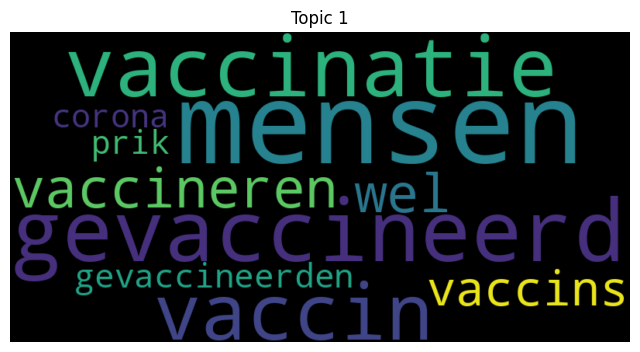

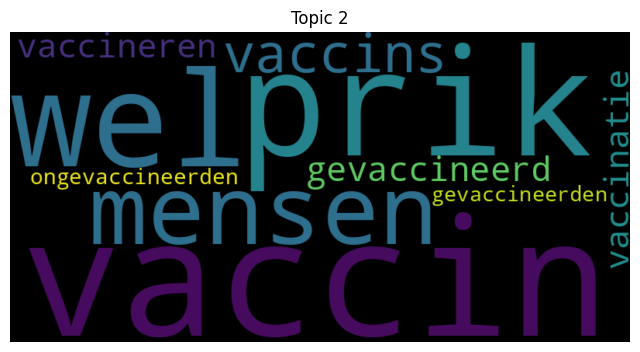

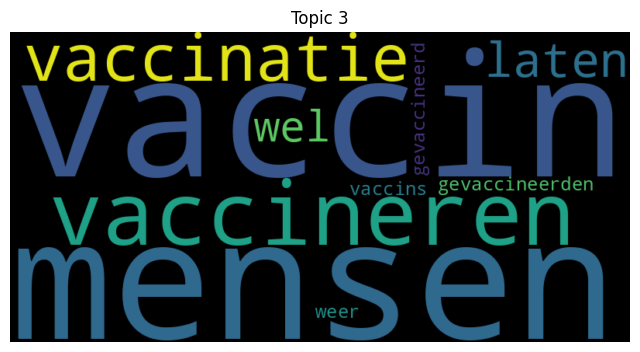

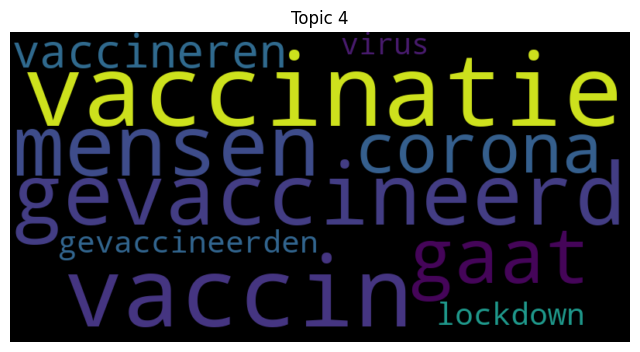

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_idx, topic in enumerate(lda_model.components_):
    plt.figure(figsize=(8, 6))
    word_frequencies = {words[i]: topic[i] for i in topic.argsort()[:-11:-1]}  # Get top words for the topic
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_frequencies)

    # Plot word cloud for the topic
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Topic {topic_idx + 1}")
    plt.axis("off")
    plt.show()

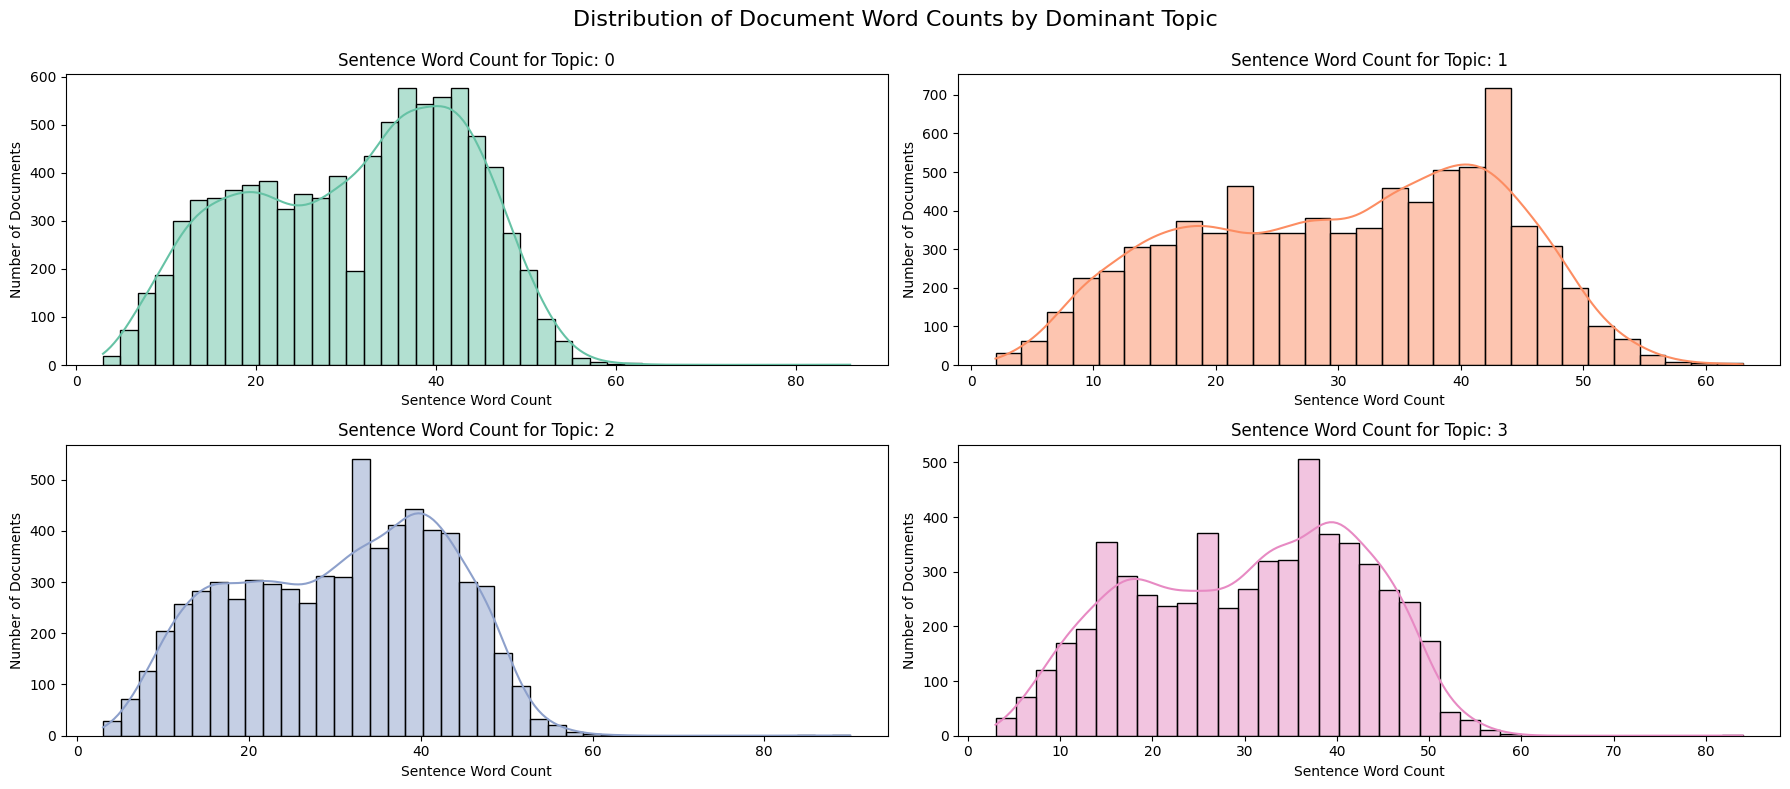

In [ ]:
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

# Get the topic distribution for each tweet
topic_distribution = lda_model.transform(training_data_LDA)

# For each topic, create a histogram or density plot
for topic_idx in range(lda_model.n_components):
    # Extract the dominant topic for each document
    dominant_topics = np.argmax(topic_distribution, axis=1)

    # Filter documents (tweets) by the dominant topic
    words_count = []
    for i in range(len(dominant_topics)):
        if dominant_topics[i] == topic_idx:
            words_count.append(len(data[i].split()))  # Count words in the document (tweet)

    # Plot the distribution for this topic
    sns.histplot(words_count, kde=True, color=sns.color_palette("Set2")[topic_idx], ax=axes[topic_idx])

    axes[topic_idx].set_title(f"Sentence Word Count for Topic: {topic_idx}")
    axes[topic_idx].set_xlabel("Sentence Word Count")
    axes[topic_idx].set_ylabel("Number of Documents")

# Add overall title
plt.suptitle("Distribution of Document Word Counts by Dominant Topic", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust top space to fit the title

plt.show()


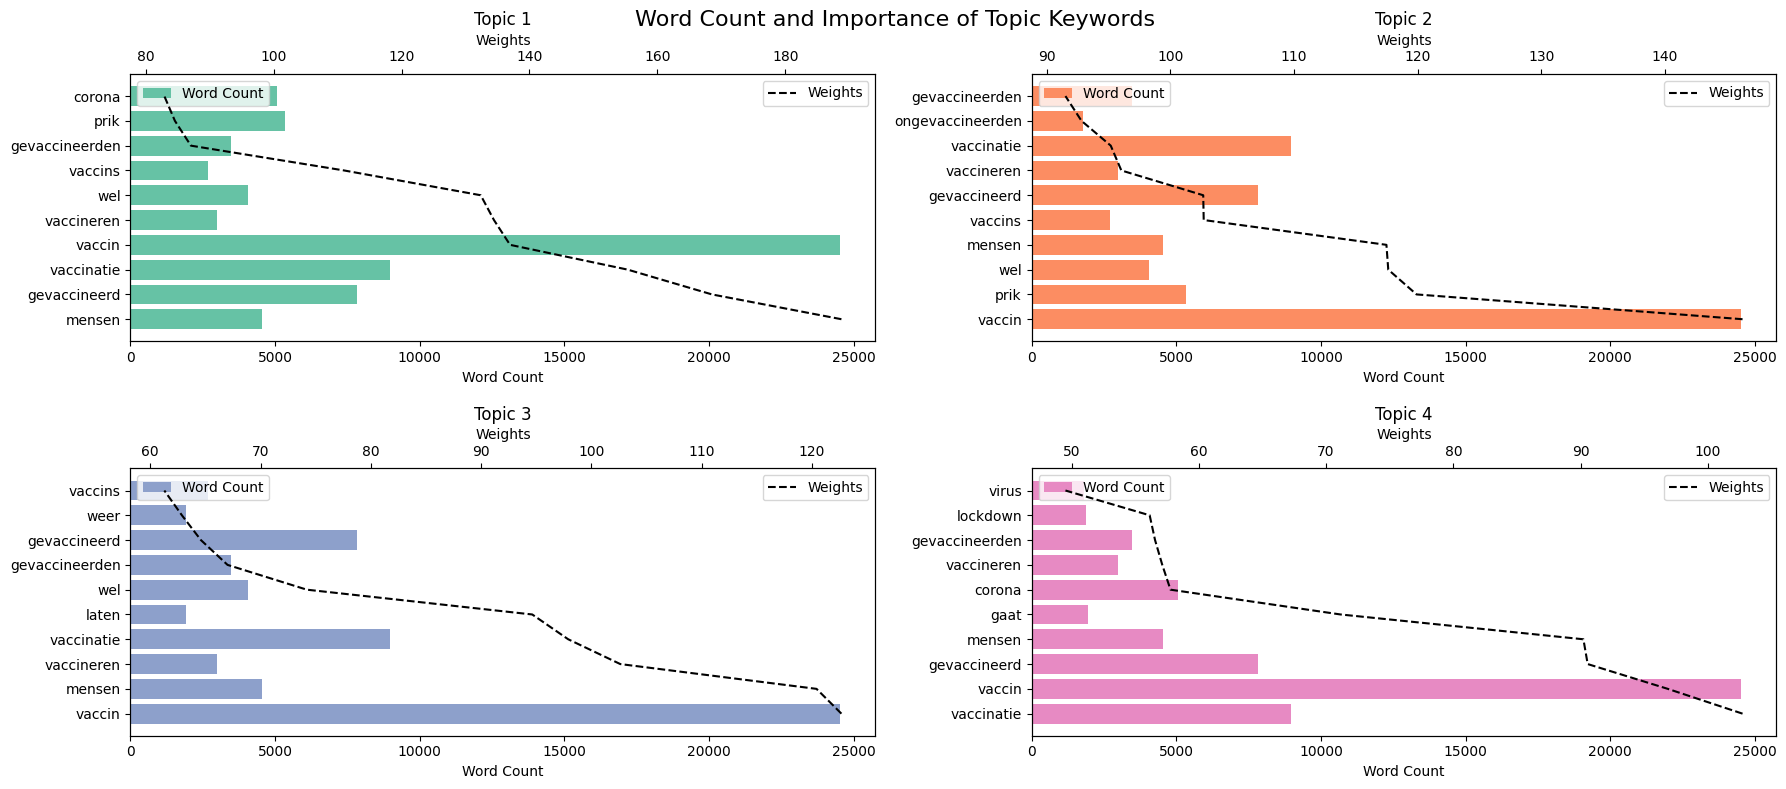

In [ ]:
n_top_words = 10

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

# Get the top words and their word counts for each topic
for topic_idx, topic in enumerate(lda_model.components_):
    # Get the top N words for this topic and their corresponding weights
    top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [words[i] for i in top_words_idx]
    top_weights = topic[top_words_idx]

    # Get the word count for these top words across all documents
    word_counts = np.zeros(n_top_words)
    for i, word in enumerate(top_words):
        word_counts[i] = sum([1 for tweet in data if word in tweet])

    # Plot word counts and weights
    ax = axes[topic_idx]
    ax.barh(top_words, word_counts, color=sns.color_palette("Set2")[topic_idx], label="Word Count")
    ax.set_xlabel("Word Count")
    ax.set_title(f"Topic {topic_idx + 1}")

    # Add weights on the side (on the right side of the bars)
    ax2 = ax.twiny()  # Create a second x-axis to plot weights
    ax2.plot(top_weights, np.arange(n_top_words), color="black", linestyle="--", label="Weights")
    ax2.set_xlabel("Weights")

    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

# Add overall title
plt.suptitle("Word Count and Importance of Topic Keywords", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust space for the main title
plt.show()


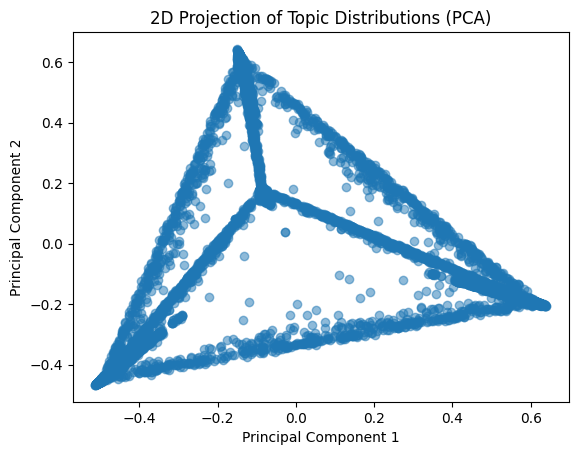

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(topic_distribution)

# Plot the 2D projection
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5)
plt.title("2D Projection of Topic Distributions (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# K-Means evaluation

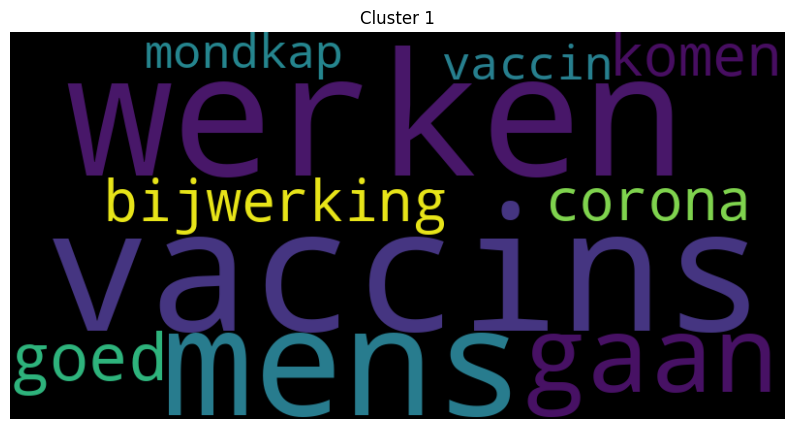

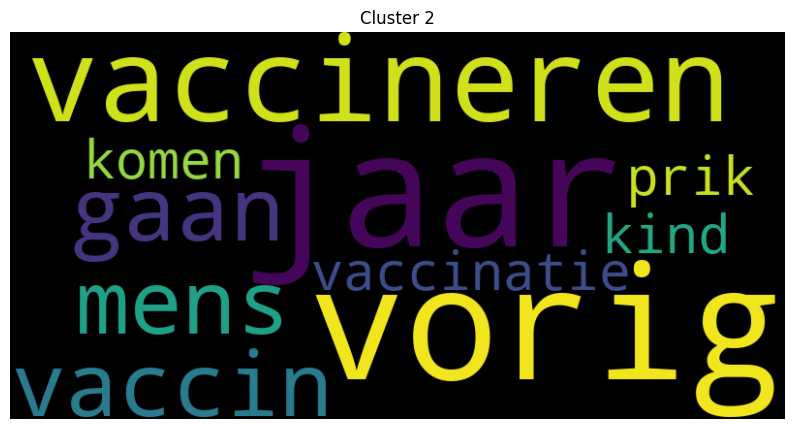

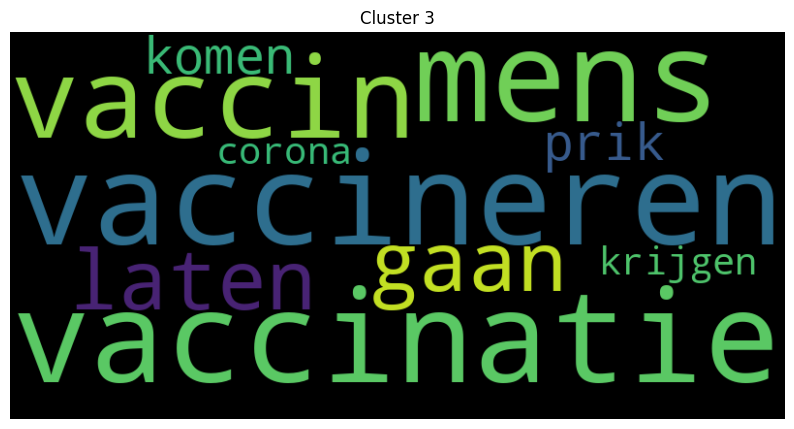

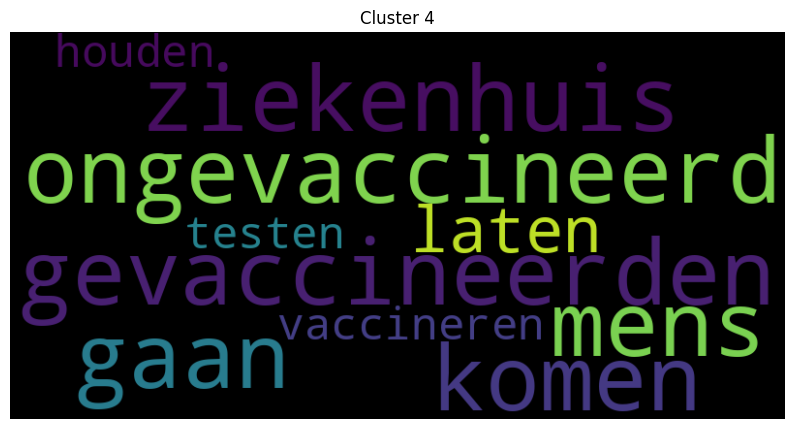

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to visualize word clouds for each cluster in separate figures
def plot_cluster_word_clouds(cluster_topics):
    for i, (cluster, terms) in enumerate(cluster_topics.items()):
        # Create a dictionary of words and their frequencies (importance)
        word_freq = {term: 1 for term in terms}  # You can adjust the frequency as needed, here it's set to 1
        wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_freq)

        # Create a new figure for each cluster
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(cluster)

        # Show the word cloud for the current cluster
        plt.show()

# Get the top terms per cluster
cluster_topics = get_top_terms_per_cluster(kmeans, vectorizer_kmeans, n_top_words)

# Visualize the word clouds for the clusters in separate figures
plot_cluster_word_clouds(cluster_topics)



Average Silhouette Score: 0.0014464126480585378


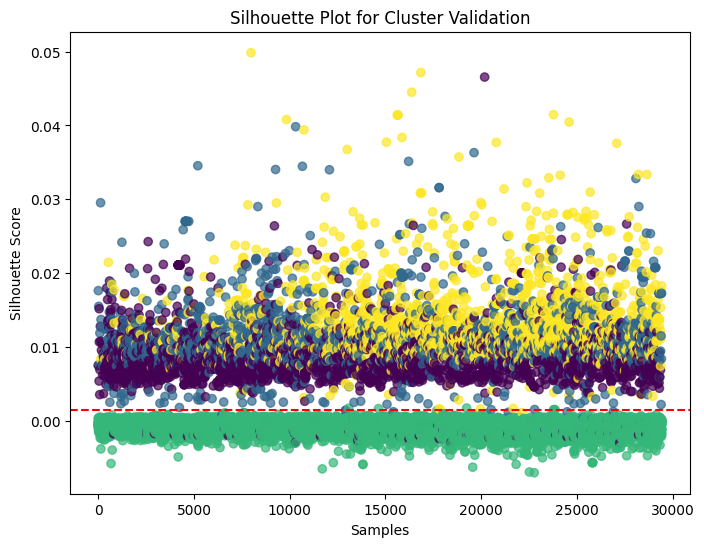

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt

silhouette_avg = silhouette_score(training_data_kmeans, labels)
print(f"Average Silhouette Score: {silhouette_avg}")

sample_silhouette_values = silhouette_samples(training_data_kmeans, labels)

plt.figure(figsize=(8, 6))
plt.scatter(range(len(sample_silhouette_values)), sample_silhouette_values, c=labels, cmap='viridis', alpha=0.7)
plt.axhline(y=silhouette_avg, color="red", linestyle="--")
plt.title("Silhouette Plot for Cluster Validation")
plt.xlabel("Samples")
plt.ylabel("Silhouette Score")
plt.show()


# Bonus Tasks

We would like to challenge you with the following bonus task. For each task that is successfully completed, you may obtain max. 1 extra point.

1. Use an LLM-based topic modeling method (for instance, **[BERTopic](https://maartengr.github.io/BERTopic/index.html)** or **[Fastopic](https://github.com/BobXWu/Fastopic)** to identify topics for your theme. Discuss your findings and explain why your chosen method is better (or worse) than LDA.

2. Can you think of other evaluation methods than the provided visualization techniques? If so, implement one and explain why it is a good evaluation for our task.

In [ ]:
!pip install bertopic
!pip install -U sentence-transformers
from bertopic import BERTopic
print("BERTopic imported successfully!")

BERTopic imported successfully!


In [ ]:
#No Vectorization Needed, also no tf-idf. Bert is good in getting the contextual relatioship between words
#Raw Cleaned Text: BERTopic requires raw text to generate embeddings internally using models like SentenceTransformers

def preprocess_for_bertopic(data, method: str = "spacy"):
    if method == "nltk":
        preprocessed_data = [preprocess_single_tweet_nltk(tweet) for tweet in data]
    elif method == "spacy":
        preprocessed_data = [preprocess_single_tweet_spacy(tweet) for tweet in data]
    else:
        raise ValueError("Invalid method. Choose either 'nltk' or 'spacy'.")
    return preprocessed_data

preprocessed_data_bertopic = preprocess_for_bertopic(Vaccine, method="spacy")


In [ ]:
#takes 20 minutes to execute

from bertopic import BERTopic
from hdbscan import HDBSCAN

# Adjusting HDBSCAN parameters for finer clustering
hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=1)

topic_model = BERTopic(
    language="multilingual",
    nr_topics=4,
    hdbscan_model=hdbscan_model
)

topics, probs = topic_model.fit_transform(preprocessed_data_bertopic)

def print_bert_topics(topic_model, n_top_words=10):
    topic_list = topic_model.get_topics()
    for topic_id, topic_terms in topic_list.items():
        if topic_id == -1:
            continue
        print(f"Topic {topic_id + 1}:")
        print(" ".join([term[0] for term in topic_terms[:n_top_words]]))
        print("\n")

print_bert_topics(topic_model)


Topic 1:
vaccineren mens vaccinatie vaccin gaan laten prik komen vaccins krijgen


Topic 2:
paprika tuin ui plantenspuit bossen boom stop spuiten eten morgen


Topic 3:
httpstcoj5e8u20eoa zomervakantie pvanhouweling verwachten prik drie verplichten zomerreis crea_marg haarlem




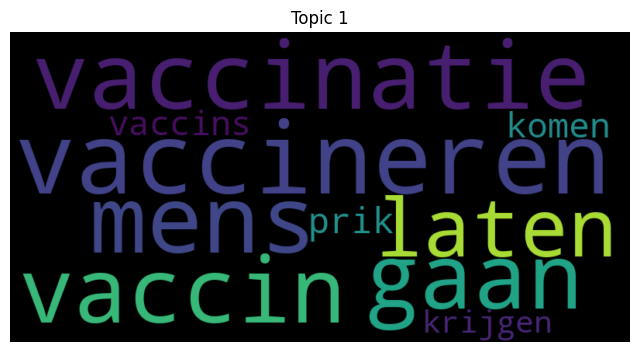

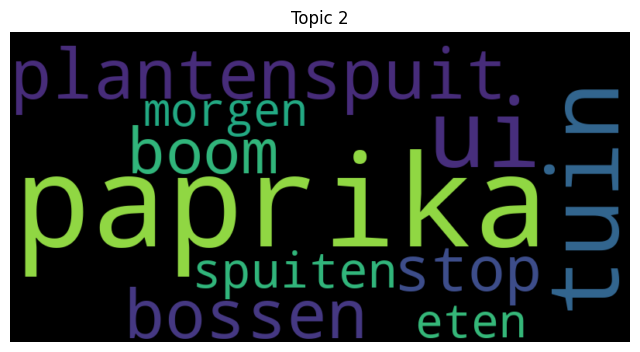

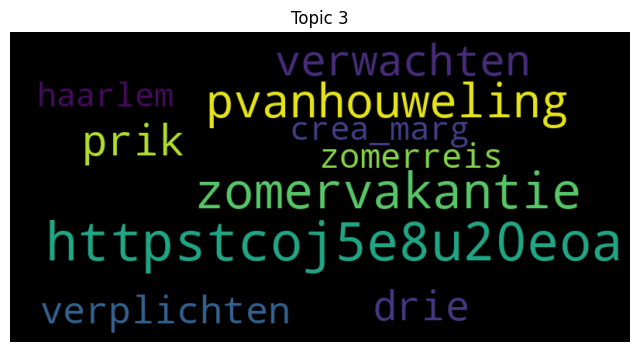

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_bertopic_wordclouds(topic_model, n_top_words=10):
    topics = topic_model.get_topics()
    for topic_id, terms in topics.items():
        if topic_id == -1:
            continue

        word_frequencies = {term[0]: term[1] for term in terms[:n_top_words]}

        wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_frequencies)

        plt.figure(figsize=(8, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.title(f"Topic {topic_id + 1}")
        plt.axis("off")
        plt.show()

create_bertopic_wordclouds(topic_model, n_top_words=10)


In [ ]:
import numpy as np

def calculate_topic_coherence(topic_words, data, top_n_words=10):

    coherence_scores = []

    for topic_id, words in topic_words.items():
        top_words = words[:top_n_words]
        co_occurrences = 0
        word_pairs = 0

        for i, word1 in enumerate(top_words):
            for word2 in top_words[i+1:]:
                word_pairs += 1
                co_occurrences += sum(1 for doc in data if word1 in doc and word2 in doc)

        # Avoid division by zero
        if word_pairs > 0:
            coherence_scores.append(co_occurrences / word_pairs)

    return np.mean(coherence_scores) if coherence_scores else 0

bertopic_topics = {
    topic_id: [term[0] for term in terms]
    for topic_id, terms in topic_model.get_topics().items()
    if topic_id != -1  # Skip outliers
}


lda_topics = {
    f"Topic {i+1}": [words[j] for j in topic.argsort()[:-n_top_words-1:-1]]
    for i, topic in enumerate(lda_model.components_)
}


kmeans_topics = {
    cluster: terms
    for cluster, terms in cluster_topics.items()
}

bertopic_coherence = calculate_topic_coherence(bertopic_topics, preprocessed_data_bertopic, top_n_words=10)
lda_coherence = calculate_topic_coherence(lda_topics, preprocessed_data_bertopic, top_n_words=10)
kmeans_coherence = calculate_topic_coherence(kmeans_topics, preprocessed_data_bertopic, top_n_words=10)

print(f"BERTopic Coherence Score: {bertopic_coherence}") #has a inaccurate score because of wrong order code execution from a earlier function with 278 topic id's.
print(f"LDA Coherence Score: {lda_coherence}")
print(f"K-means Coherence Score: {kmeans_coherence}")


BERTopic Coherence Score: 11.050970673275504
LDA Coherence Score: 864.9666666666667
K-means Coherence Score: 860.8499999999999
